# Question 1: Illegal Desposed Waste and Littering in the neighbourhoods of Zürich

Author: Tim Berger 
Date: 20.5.2026

#### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city. 
Reports are sorted in different categories, such as waste or graphity. 
Illegal disposed waste and littering in the "Abfall/ Sammelstelle" category is reported the most (see category frequency analysis).
As seen in the heatmap, the number of reports is, generally speaking, higher in the centre of Zürich, compared to the outer regions. But at the same time, also more people live in the city center compared to the outer regions. Therefore this analysis aims to compare the number of reports per resident for the neighbourhoods of Zurich.

#### Research Question: 
Do the waste report hotspots on the heatmap correlate with the reports per resident for the neighbourhoods of zurich?

#### Requirements
To be able to run this code, use the environment sds210 located in the github repository of this project.

import packages


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats

import notebook_utils

### Access and load data via Website of Zürich (züri wie neu, neighbourhoods, population)

In [2]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()
neighbourhoods_gdf_raw = notebook_utils.import_neighbourhood_data()
population_df_raw = notebook_utils.import_population_data()
income_df_raw = notebook_utils.import_income_data()


Data züri wie neu loaded sugessfull
Data züri wie neu loaded sugessfull
Data Population loaded sugessfull
Data Income loaded sugessfull


## Clean and Filter the Data

- clean population data

In [3]:
## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

#clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

#convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

#rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})



- clean züri wie neu data

In [4]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]


- clean neighbourhood data

In [ ]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]



<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   qname     34 non-null     str     
 1   qnr       34 non-null     int32   
 2   geometry  34 non-null     geometry
dtypes: geometry(1), int32(1), str(1)
memory usage: 1.1 KB


## join and merge data together

In [17]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")


#count the number of waste per neighbourhood and safe it as a dataframe waste_income_df
waste_pop_df = waste_with_neighbourhoods_df[["qname"]].value_counts().to_frame()

#rename the dataframe
waste_pop_df = waste_pop_df.rename(columns={"count":"count_waste"})

waste_pop_df.info()


<class 'pandas.DataFrame'>
MultiIndex: 34 entries, ('Langstrasse',) to ('Saatlen',)
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   count_waste  34 non-null     int64
dtypes: int64(1)
memory usage: 933.0 bytes


In [18]:
# merge the population to the neighbourhoods

waste_pop_df = pd.merge(right=waste_pop_df, 
                                        left=population_df,
                                        left_on="qname",
                                        right_on="qname")
waste_pop_df = waste_pop_df.sort_values(by="population", ascending=True)
waste_pop_df = waste_pop_df.set_index("qname")

waste_pop_df.info()


<class 'pandas.DataFrame'>
Index: 34 entries, Hochschulen to Altstetten
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   population   34 non-null     int64
 1   count_waste  34 non-null     int64
dtypes: int64(2)
memory usage: 1.1 KB


In [26]:
# merge the population and waste to the geometry and calculate the pop density and waste per resident
waste_pop_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_pop_df,
                                        left_on="qname",
                                        right_on="qname")

# calculate the population density
waste_pop_gdf["population_density"] = waste_pop_gdf["population"]/waste_pop_gdf.geometry.area


# normalize the waste per 100 person
waste_pop_gdf["waste_per_pop"] = 100* waste_pop_gdf["count_waste"]/waste_pop_gdf["population"] 

# normalize the waste per area
waste_pop_gdf["waste_per_area"] = 100* waste_pop_gdf["count_waste"]/waste_pop_gdf.geometry.area

# sort neighbourhoods by population density
waste_pop_gdf = waste_pop_gdf.sort_values(by= "population_density", ascending=True)


## Plot Data

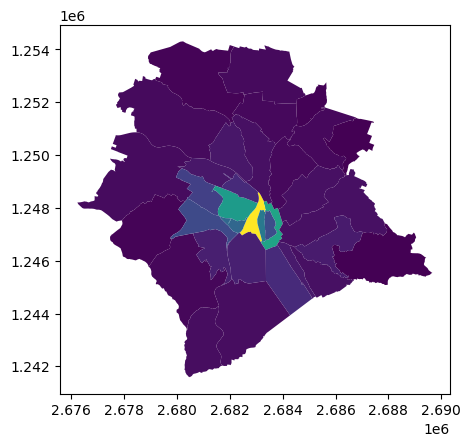

In [28]:
fig, ax = plt.subplots()
waste_pop_gdf.plot(ax=ax, column= "waste_per_pop")

plt.show()

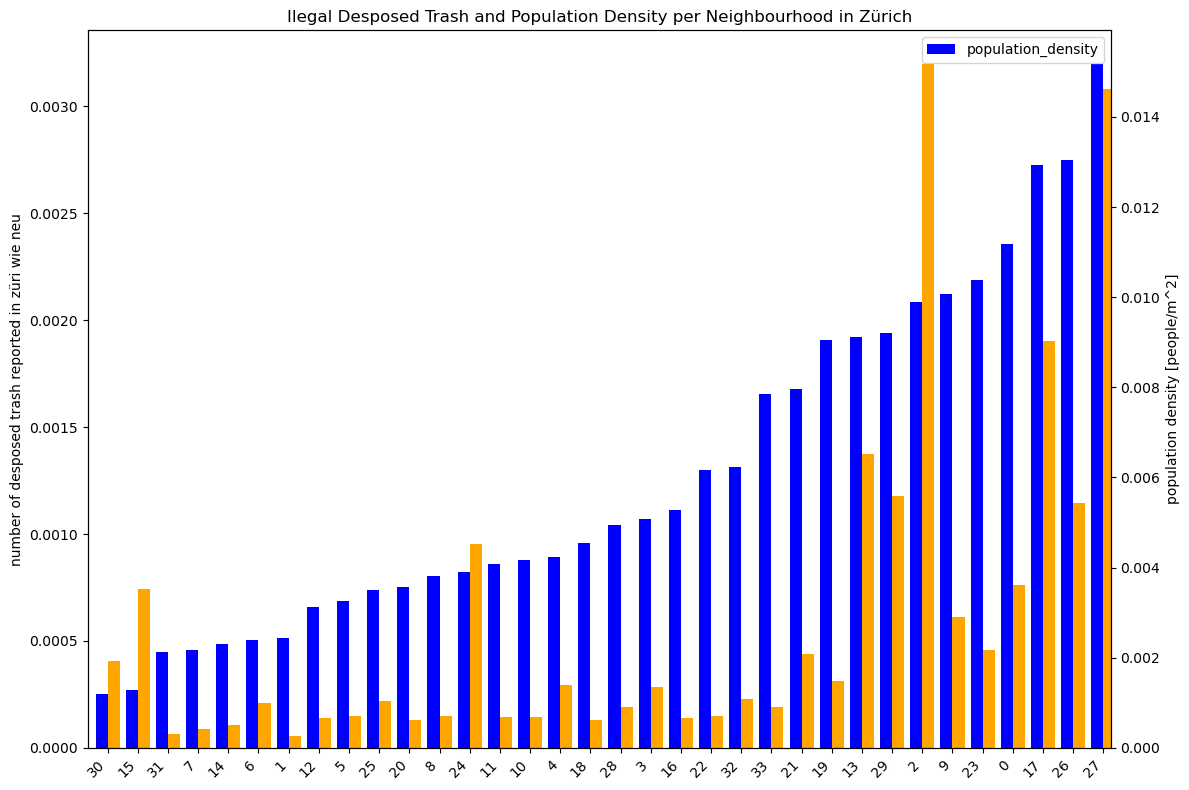

In [ ]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

waste_pop_gdf["waste_density"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Population Density per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
waste_pop_gdf["population_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="population density [people/m^2]"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()
plt.legend()


plt.show()

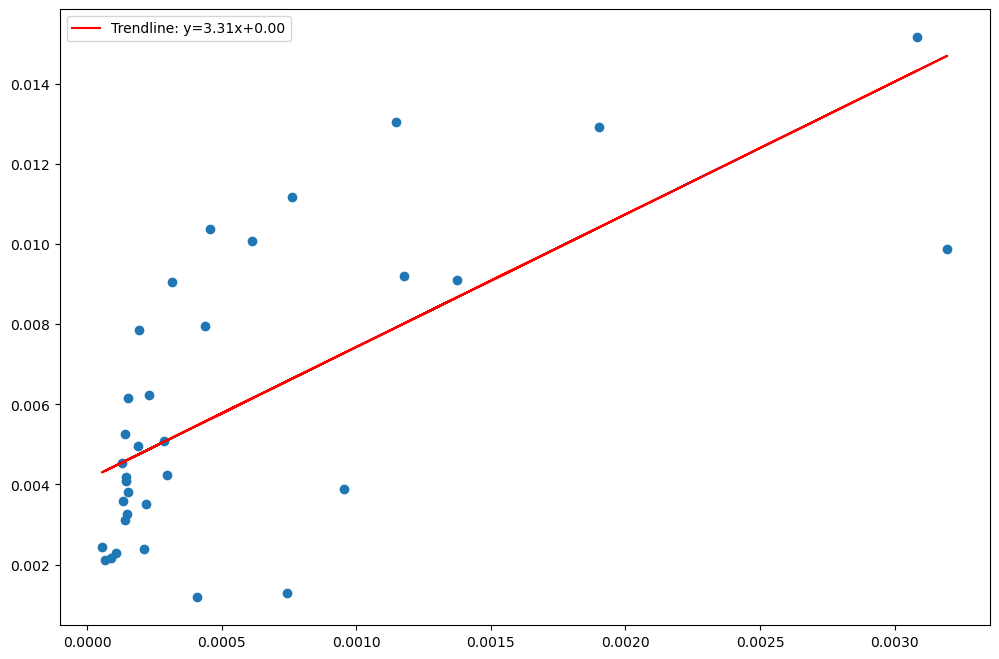

In [ ]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(waste_pop_gdf["waste_density"], waste_pop_gdf["population_density"])
m, b = np.polyfit(waste_pop_gdf["waste_density"], waste_pop_gdf["population_density"], 1)
x= waste_pop_gdf["waste_density"]
y= waste_pop_gdf["population_density"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


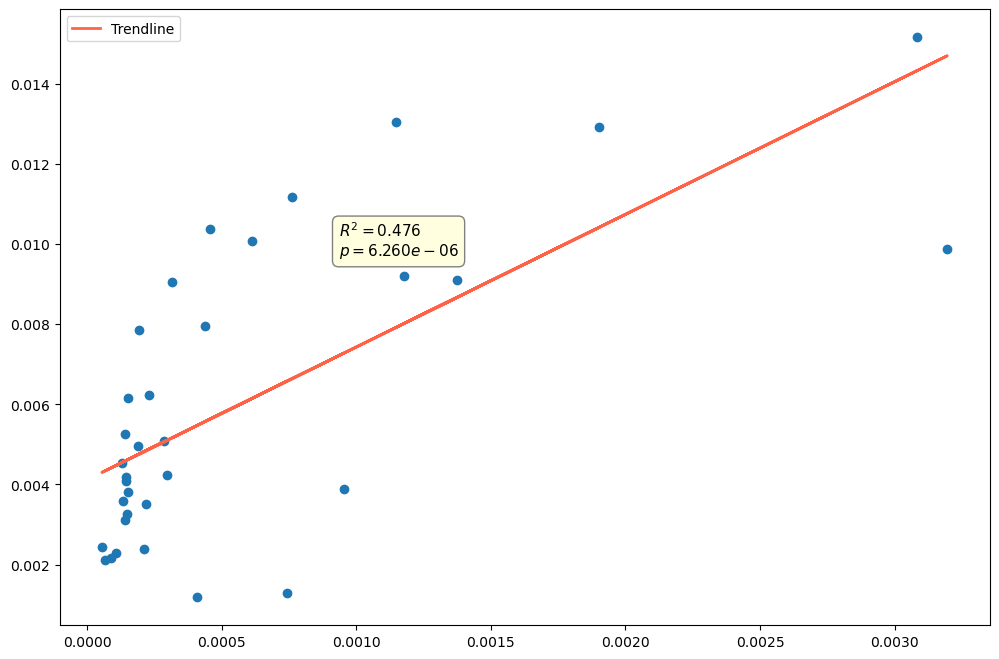

In [ ]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= waste_pop_gdf["waste_density"]
y= waste_pop_gdf["population_density"]

ax3.scatter(x,y)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='tomato', linewidth=2, label='Trendline')
x= waste_pop_gdf["waste_density"]
y= waste_pop_gdf["population_density"]

ax3.annotate(
    f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()